# Edge cases

> Whole-workflow tests: a file goes in, a figure and a zone table come out, and everything is checked.

Each case below is the kind of data that has broken diagrams before: empty overlaps, a bait with no hits, one set inside another, single proteins. For every case this notebook:

1. writes the sets to a file, as a user would;
2. runs the `itemiset` command on it, writing a PNG and a zone table;
3. checks the figure exists, that the zone table lists every item once in the right zone, and that the layout passes all five checks;
4. checks the notes: filler cells and missing sets must always be reported.

The same steps run for the Python API and for Venn mode. When run as a test (`nbdev-test`), any failure stops the build.

In [ ]:
import tempfile
from pathlib import Path

import pandas as pd
from fastcore.test import *

from itemiset.cli import run
from itemiset.layout import CHECKS, check_layout, layout_sets
from itemiset.render import plot
from itertools import combinations
from matplotlib.figure import Figure
import matplotlib.image as mpimg
import io
from IPython.display import Image

In [ ]:
def from_zones(spec, names=("Bait1", "Bait2", "Bait3")):
    "Sets from zone sizes, e.g. {'A': 3, 'AB': 2}. Items are named after their zone."
    code = dict(zip("ABC", names))
    k = max("ABC".index(ch) + 1 for z in spec for ch in z)
    sets = {code[ch]: [] for ch in "ABC"[:k]}
    for z, n in spec.items():
        for j in range(n):
            for ch in z: sets[code[ch]].append(f"{z}_{j:02d}")
    return sets

def write_wide(sets, path):
    "Write sets as one column per set, padding with blanks."
    n = max([len(v) for v in sets.values()] + [1])
    pd.DataFrame({k: v + [""] * (n - len(v)) for k, v in sets.items()}).to_csv(path, index=False)

## The cases

Each case gives zone sizes, options, and what the notes must say.

In [ ]:
CASES = [
    ("All seven zones filled",          {"A": 30, "B": 20, "C": 15, "AB": 8, "AC": 6, "BC": 10, "ABC": 5}, {}, []),
    ("No triple overlap",               {"A": 30, "B": 20, "C": 15, "AB": 8, "AC": 6, "BC": 10}, {}, []),
    ("Bait3 shares nothing",            {"A": 30, "B": 20, "AB": 8, "C": 12}, {}, []),
    ("All three disjoint",              {"A": 30, "B": 20, "C": 12}, {}, []),
    ("Bait3 inside Bait1 ∩ Bait2",      {"A": 30, "B": 20, "AB": 12, "ABC": 6}, {}, []),
    ("Single-member zones",             {"A": 1, "B": 1, "ABC": 1}, {}, []),
    ("Bait3 found nothing",             {"A": 30, "B": 20, "C": 0}, {}, ["no members"]),
    ("Filler avoided automatically",    {"A": 3, "B": 3, "AB": 2, "AC": 3, "BC": 3}, {}, []),
    ("Filler needed: Bait3 forced down", {"A": 3, "B": 3, "AB": 2, "AC": 3, "BC": 3}, {"bottom": "Bait3"}, ["filler"]),
    ("Two sets",                        {"A": 12, "B": 9, "AB": 5}, {}, []),
    ("One set",                         {"A": 17}, {}, []),
]

## Running them through the command line

In [ ]:
tmp = Path(tempfile.mkdtemp())
results = []
for i, (title, spec, opts, must_note) in enumerate(CASES):
    sets = from_zones(spec)
    src, png, zones = tmp/f"case{i:02d}.csv", tmp/f"case{i:02d}.png", tmp/f"case{i:02d}_zones.csv"
    write_wide(sets, src)
    args = [str(src), "-o", str(png), "--zones-out", str(zones), "--title", title]
    if "bottom" in opts: args += ["--bottom", opts["bottom"]]
    lay = run(args)

    # the figure exists
    assert png.exists() and png.stat().st_size > 2000, title
    # every item is listed once, in the right zone
    zt = pd.read_csv(zones)
    want = {item: sorted(s for s, v in sets.items() if item in v) for v in sets.values() for item in v}
    test_eq(sorted(zt["item"]), sorted(want))
    for _, row in zt.iterrows():
        test_eq(sorted(s for s in sets if s in zt.columns and row[s] == 1), want[row["item"]])
    # the layout is sound
    res = check_layout(lay, sets)
    assert all(res.values()), (title, res)
    # nothing goes unreported
    for word in must_note: assert any(word in n for n in lay.notes), (title, lay.notes)
    if "filler" not in must_note: test_eq(lay.n_filler, 0)
    results.append(dict(case=title, items=lay.n_items, cells=len(lay.cells), filler=lay.n_filler,
                        bottom=lay.roles.get("C", ""), notes=" ".join(lay.notes), **res))

pd.DataFrame(results)

Wrote /tmp/tmpit11j9e5/case00.png
Roles: A=Bait2, B=Bait3, C=Bait1 | group widths (L, M, R): (4, 3, 3)
  Bait1                                            30
  Bait2                                            20
  Bait3                                            15
  Bait1 ∩ Bait3                                     6
  Bait1 ∩ Bait2                                     8
  Bait2 ∩ Bait3                                    10
  Bait1 ∩ Bait2 ∩ Bait3                             5


Wrote /tmp/tmpit11j9e5/case01.png
Roles: A=Bait2, B=Bait3, C=Bait1 | group widths (L, M, R): (4, 2, 3)
  Bait1                                            30
  Bait2                                            20
  Bait3                                            15
  Bait1 ∩ Bait3                                     6
  Bait1 ∩ Bait2                                     8
  Bait2 ∩ Bait3                                    10


Wrote /tmp/tmpit11j9e5/case02.png
Roles: A=Bait1, B=Bait2, C=Bait3 | group widths (L, M, R): (4, 1, 3)
  Bait1                                            30
  Bait2                                            20
  Bait3                                            12
  Bait1 ∩ Bait2                                     8
Wrote /tmp/tmpit11j9e5/case03.png
Roles: A=Bait1, B=Bait3, C=Bait2 | group widths (L, M, R): (5, 0, 2)
  Bait1                                            30
  Bait2                                            20
  Bait3                                            12


Wrote /tmp/tmpit11j9e5/case04.png
Roles: A=Bait1, B=Bait3, C=Bait2 | group widths (L, M, R): (6, 1, 0)
  Bait1                                            30
  Bait2                                            20
  Bait1 ∩ Bait2                                    12
  Bait1 ∩ Bait2 ∩ Bait3                             6
Wrote /tmp/tmpit11j9e5/case05.png
Roles: A=Bait2, B=Bait3, C=Bait1 | group widths (L, M, R): (1, 1, 0)
  Bait1                                             1
  Bait2                                             1
  Bait1 ∩ Bait2 ∩ Bait3                             1
Wrote /tmp/tmpit11j9e5/case06.png
Roles: A=Bait1, B=Bait2 | group widths (L, M, R): (4, 0, 3)
  Bait1                                            30
  Bait2                                            20
Note: Set 'Bait3' has no members and was left out of the diagram.


Wrote /tmp/tmpit11j9e5/case07.png
Roles: A=Bait2, B=Bait3, C=Bait1 | group widths (L, M, R): (1, 1, 1)
  Bait1                                             3
  Bait2                                             3
  Bait1 ∩ Bait3                                     3
  Bait1 ∩ Bait2                                     2
  Bait2 ∩ Bait3                                     3
Wrote /tmp/tmpit11j9e5/case08.png
Roles: A=Bait1, B=Bait2, C=Bait3 | group widths (L, M, R): (1, 1, 1)
  Bait1                                             3
  Bait2                                             3
  Bait1 ∩ Bait3                                     3
  Bait1 ∩ Bait2                                     2
  Bait2 ∩ Bait3                                     3
Note: 3 blank filler cell(s) added to 'Bait3 only' to keep that set connected.
Wrote /tmp/tmpit11j9e5/case09.png
Roles: A=Bait1, B=Bait2 | group widths (L, M, R): (2, 1, 2)
  Bait1                                            12
  Bait2                    

Wrote /tmp/tmpit11j9e5/case10.png
Roles: A=Bait1 | group widths (L, M, R): (4,)
  Bait1                                            17


,case,items,cells,filler,bottom,notes,One cell per item,Each set is one piece,No set has a hole,Each zone is one piece,No stray white pockets
0,All seven zones filled,94,94,0,Bait1,,True,True,True,True,True
1,No triple overlap,89,89,0,Bait1,,True,True,True,True,True
2,Bait3 shares nothing,70,70,0,Bait3,,True,True,True,True,True
3,All three disjoint,62,62,0,Bait2,,True,True,True,True,True
4,Bait3 inside Bait1 ∩ Bait2,68,68,0,Bait2,,True,True,True,True,True
5,Single-member zones,3,3,0,Bait1,,True,True,True,True,True
6,Bait3 found nothing,50,50,0,,Set 'Bait3' has no members and was left out of...,True,True,True,True,True
7,Filler avoided automatically,14,14,0,Bait1,,True,True,True,True,True
8,Filler needed: Bait3 forced down,14,17,3,Bait3,3 blank filler cell(s) added to 'Bait3 only' t...,True,True,True,True,True
9,Two sets,26,26,0,,,True,True,True,True,True


## Venn mode and the Python API

The same cases with `show_empty=True`. Every empty zone between drawn sets must get exactly one ∅ cell.

In [ ]:
for title, spec, opts, _ in CASES:
    sets = from_zones(spec)
    lay = layout_sets(sets, show_empty=True, **opts)
    assert all(check_layout(lay, sets).values()), title
    drawn = [s for s in sets if sets[s]]
    zones = {frozenset(c) for k in range(1, len(drawn) + 1) for c in combinations(drawn, k)}
    empty = {z for z in zones if not any(set(z) == {s for s in sets if it in sets[s]} for v in sets.values() for it in v)}
    test_eq(sum(c.placeholder for c in lay.cells), len(empty))

## Other file formats

A membership table, and an Excel workbook with a categories sheet, go through the same command:

In [ ]:
sets = from_zones({"A": 4, "B": 3, "AB": 2, "ABC": 1, "C": 2})
items = list(dict.fromkeys(i for v in sets.values() for i in v))
table = pd.DataFrame({"gene": items, **{s: [int(i in v) for i in items] for s, v in sets.items()}})
table["category"] = ["Shared" if i.startswith("AB") else "" for i in items]
table.to_csv(tmp/"membership.csv", index=False)
lay = run([str(tmp/"membership.csv"), "-o", str(tmp/"membership.svg")])
assert all(check_layout(lay, sets).values())
svg = (tmp/"membership.svg").read_text()
assert all(f">{i}</text>" in svg for i in items)   # every name is live text in the SVG

with pd.ExcelWriter(tmp/"book.xlsx") as w:
    pd.DataFrame({k: pd.Series(v) for k, v in sets.items()}).to_excel(w, sheet_name="sets", index=False)
    pd.DataFrame({"gene": ["AB_00"], "category": ["Shared"], "color": ["#2140A8"]}).to_excel(w, sheet_name="categories", index=False)
lay = run([str(tmp/"book.xlsx"), "--sheet", "sets", "-o", str(tmp/"book.png")])
assert all(check_layout(lay, sets).values())

Wrote /tmp/tmpit11j9e5/membership.svg
Roles: A=Bait1, B=Bait2, C=Bait3 | group widths (L, M, R): (1, 1, 1)
  Bait1                                             4
  Bait2                                             3
  Bait3                                             2
  Bait1 ∩ Bait2                                     2
  Bait1 ∩ Bait2 ∩ Bait3                             1
Wrote /tmp/tmpit11j9e5/book.png
Roles: A=Bait1, B=Bait2, C=Bait3 | group widths (L, M, R): (1, 1, 1)
  Bait1                                             4
  Bait2                                             3
  Bait3                                             2
  Bait1 ∩ Bait2                                     2
  Bait1 ∩ Bait2 ∩ Bait3                             1


## Contact sheet

All the command-line figures, for a quick look:

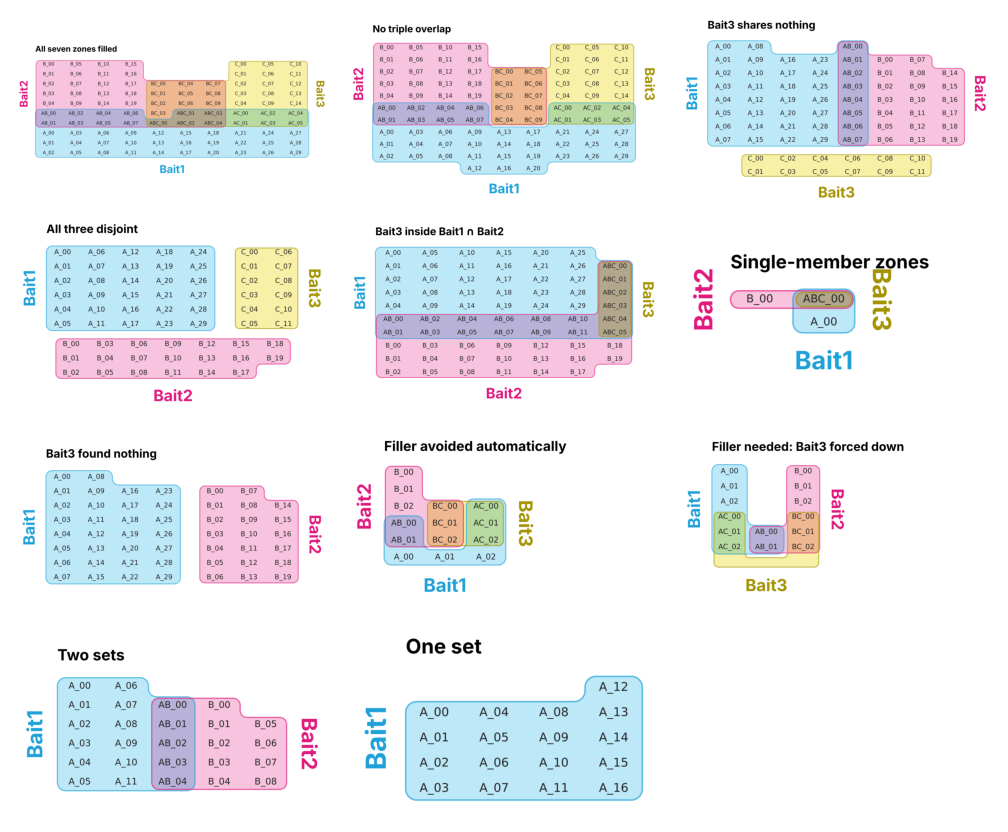

In [ ]:
pngs = sorted(tmp.glob("case*.png"))
cols = 3; rows = -(-len(pngs) // cols)
fig = Figure(figsize=(cols * 4.2, rows * 2.6))
for k, p in enumerate(pngs):
    ax = fig.add_subplot(rows, cols, k + 1)
    ax.imshow(mpimg.imread(p)); ax.axis("off")
fig.tight_layout()
buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=80)
Image(data=buf.getvalue())